<a href="https://colab.research.google.com/github/MinhPhuc0227/Customer-Churn-Analysis-Prediction/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Link dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

# **1. Import thư viện & load bộ dữ liệu**

In [20]:
# Xử lý & trực quan hóa dữ liệu
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

# Tiền xử lý dữ liệu
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Các mô hình Machine Learning sử dụng
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
import xgboost as xgb
import lightgbm as lgb

# Đánh giá mô hình
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve,roc_auc_score, auc, f1_score)

# Khác
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Load bộ dữ liệu
dataset = pd.read_csv("/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [22]:
# Cài đặt hiển thị tất cả các cột của bộ dữ liệu
pd.set_option('display.max_columns', None)


# **2. Xem qua bộ dữ liệu**

In [23]:
# Xem qua nội dung của bộ dữ liệu
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
# Xem thông tin tổng quan của bộ dữ liệu
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [25]:
# Xem số dòng và số cột của bộ dữ liệu
print("Số dòng của bộ dữ liệu: ", dataset.shape[0])
print("Số cột (đặc trưng) của bộ dữ liệu: ", dataset.shape[1])

Số dòng của bộ dữ liệu:  7043
Số cột (đặc trưng) của bộ dữ liệu:  21


In [26]:
# Lấy các đặc trưng kiểu chuỗi
object_columns = dataset.select_dtypes(include=['object']).columns
print("Số đặc trưng kiểu chuỗi:", len(object_columns))
# Tạo bảng
object_table = pd.DataFrame({
    "Đặc trưng": object_columns,
    "Số giá trị khác nhau": dataset[object_columns].nunique()
})
object_table = object_table.sort_values(by="Số giá trị khác nhau", ascending=False).reset_index(drop=True)
object_table

Số đặc trưng kiểu chuỗi: 18


,Đặc trưng,Số giá trị khác nhau
0,customerID,7043
1,TotalCharges,6531
2,PaymentMethod,4
3,Contract,3
4,MultipleLines,3
5,OnlineBackup,3
6,DeviceProtection,3
7,TechSupport,3
8,OnlineSecurity,3
9,InternetService,3


Ngoài customerID và TotalCharges có rất nhiều giá trị khác nhau, các đặc trưng còn lại đều chỉ có từ 2-4 giá trị, nên ta sẽ xem các đặc trưng có ít giá trị khác nhau này là các đặc trưng phân loại.

In [27]:
# Lấy các đặc trưng kiểu số (int/float)
number_columns = dataset.select_dtypes(include=['number']).columns
print("Số đặc trưng kiểu số:", len(number_columns))

number_table = pd.DataFrame({
    "Đặc trưng": number_columns,
    "Số giá trị khác nhau": dataset[number_columns].nunique()
})
number_table = number_table.sort_values(by="Số giá trị khác nhau", ascending=False).reset_index(drop=True)
number_table

Số đặc trưng kiểu số: 3


,Đặc trưng,Số giá trị khác nhau
0,MonthlyCharges,1585
1,tenure,73
2,SeniorCitizen,2


# **3. Tiền xử lý dữ liệu**

Kiểm tra giá trị thiếu và giá trị trùng lặp

In [28]:
# Kiểm tra giá trị thiếu
print("Giá trị thiếu: ", dataset.isna().sum().sum())
# Kiểm tra giá trị trùng lặp
print("Giá trị trùng lặp: ", dataset.duplicated().sum())

Giá trị thiếu:  0
Giá trị trùng lặp:  0


Phát hiện và loại bỏ đặc trưng không cần thiết:


*   Có thể thấy, **'customerID**' là mã định danh của mỗi khách hàng, không liên quan đến hành vi rời bỏ, do đó không ảnh hưởng đến kết quả dự đoán của mô hình.
*   Ta sẽ xóa **'customerID'** khỏi bộ dữ liệu để tập trung vào các đặc trưng quan trọng, giảm số chiều dữ liệu để huấn luyện mô hình hiệu quả hơn.

In [29]:
# Tạo dataset khác copy bộ dữ liệu gốc
df = dataset.copy()
# Drop 'customerID' ra khỏi bộ dữ liệu
df = df.drop(columns='customerID')
# Kiểm tra lại các đặc trưng trong bộ dữ liệu
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Trong danh sách các đặc trưng kiểu chuỗi, có thể thấy **TotalCharges** có đến 6531 giá trị khác nhau và giá trị trong cột có kiểu số, nên ta sẽ chuyển đổi kiểu dữ liệu của **TotalCharges** từ dạng chuỗi sang dạng số.

errors = 'coerce' sẽ hỗ trợ ép các giá trị không chuyển đổi được thành **NaN**, do đó sau khi chuyển đổi ta phải kiểm tra **TotalCharges** có bao nhiêu giá trị **NaN**.

In [30]:
# Chuyển đổi kiểu dữ liệu của TotalCharges từ dạng chuỗi sang dạng số
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Kiểm tra lại kiểu dữ liệu của TotalCharges
print("Kiểu dữ liệu hiện tại của TotalCharges: ", df['TotalCharges'].dtype)
# Kiểm tra số giá trị NaN của ToltalCharges
print("Số giá trị NaN sau khi chuyển đổi: ", df['TotalCharges'].isna().sum())

Kiểu dữ liệu hiện tại của TotalCharges:  float64
Số giá trị NaN sau khi chuyển đổi:  11


In [31]:
# Xem thử các dòng chứa giá trị NaN
print("Các dòng hiện tại đang chứa giá trị NaN: ")
df[df['TotalCharges'].isna()]

Các dòng hiện tại đang chứa giá trị NaN: 


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


> Có thể nhận thấy, tất cả các khách hàng không được ghi nhận giá trị **TotalCharges** đều có **tenure** = 0 và giá trị trị **Churn** là No, tức là không rời bỏ.

> Như vậy có khả năng các khách hàng này là khách hàng mới (tenure = 0) và chưa phát sinh thanh toán (TotalCharges trống). Do đó, để bảo toàn dữ liệu khách hàng và có thể xử lý các khách hàng mới trong bộ dữ liệu, nhóm sẽ sử dụng **phương pháp điền (fill)** các giá trị bị thiếu trong **TotalCharges** của các khách hàng này là 0.

In [32]:
# Xử lý giá trị bị thiếu
df['TotalCharges'] = df['TotalCharges'].fillna(0)
# Kiểm tra lại toàn bộ dataset
print("Số giá trị bị thiếu trong bộ dữ liệu sau khi xử lý: ", df.isna().sum().sum())

Số giá trị bị thiếu trong bộ dữ liệu sau khi xử lý:  0


Tiếp theo, trong danh sách các đặc trưng kiểu số, **SeniorCitizen** chỉ có 2 giá trị khác nhau, ta sẽ xem thử 2 giá trị đó là gì.

In [33]:
# Xem giá trị của SeniorCitizen
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


Có thể thấy **SeniorCitizen** chỉ gồm hai giá trị phân loại là 1 và 0, nên ta sẽ chuyển đổi kiểu dữ liệu của **SeniorCitzen** từ kiểu số sang kiểu chuỗi

In [34]:
# Chuyển đổi kiểu dữ liệu của SeniorCitizen từ numeric sang object
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')
# Kiểm tra lại kiểu dữ liệu của SeniorCitizen
print("Kiểu dữ liệu hiện tại của SeniorCitizen: ", df['SeniorCitizen'].dtype)

Kiểu dữ liệu hiện tại của SeniorCitizen:  object


Sau khi hoàn thành việc chuyển đổi dữ liệu, ta sẽ tạo lại danh sách các cột kiểu phân loại và kiểu số để phục vụ việc phân tích và trực quan hóa dữ liệu được rõ ràng và chính xác hơn.

In [35]:
# Tạo lại danh sách các cột kiểu phân loại và kiểu số
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
# Kiểm tra lại tất cả thay đổi
print("Số cột categorical:", len(categorical_columns))
for column in categorical_columns:
    print(column)
print("\nSố cột numeric:", len(numeric_columns))
for column in numeric_columns:
    print(column)

Số cột categorical: 17
gender
SeniorCitizen
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
Churn

Số cột numeric: 3
tenure
MonthlyCharges
TotalCharges


Tổng hợp các thay đổi đã thực hiện trong phần này:
*   Loại bỏ đặc trưng 'customerID' ra khỏi bộ dữ liệu
*   Chuyển đổi kiểu dữ liệu của TotalCharges từ dạng chuỗi sang dạng số
*   Chuyển đổi kiểu dữ liệu của SeniorCitizen từ dạng số sang dạng chuỗi
*   Tạo lại danh sách các cột kiểu phân loại và kiểu số để phù hợp cho việc phân tích và trực quan hóa dữ liệu





# **4. Trực quan hóa dữ liệu**

**Biểu đồ trực quan các biến đặc trưng và biến mục tiêu trong bộ dữ liệu**

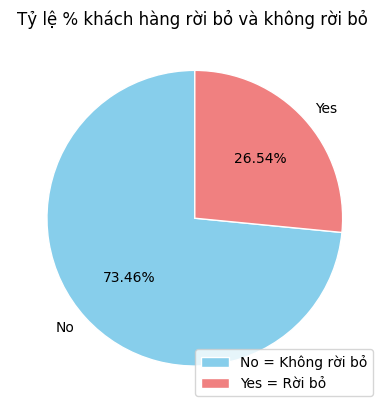

In [36]:
# Biểu đồ tròn thể hiện tỷ lệ % khách hàng rời bỏ và không rời bỏ trong bộ dữ liệu
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    colors= ["skyblue", "lightcoral"],
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)
plt.title('Tỷ lệ % khách hàng rời bỏ và không rời bỏ ')
plt.legend(labels=['No = Không rời bỏ', 'Yes = Rời bỏ'], loc='lower right')
plt.ylabel('')
plt.show()

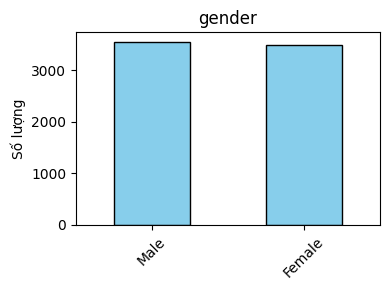

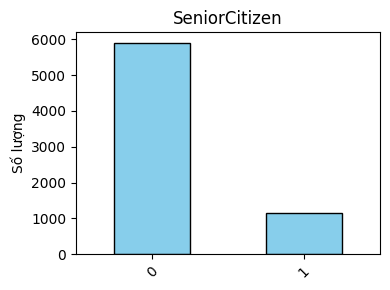

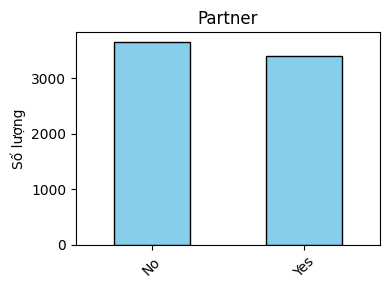

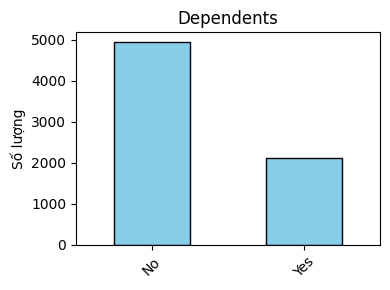

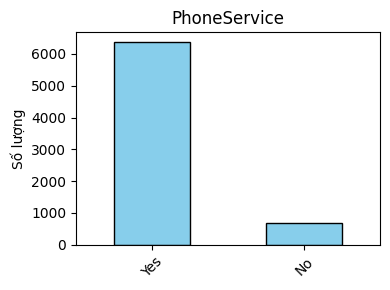

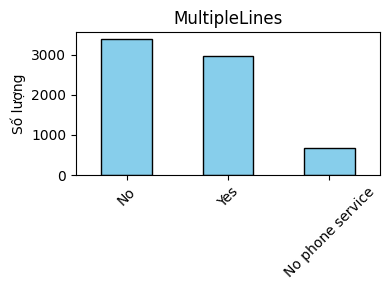

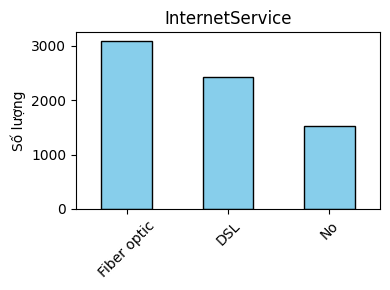

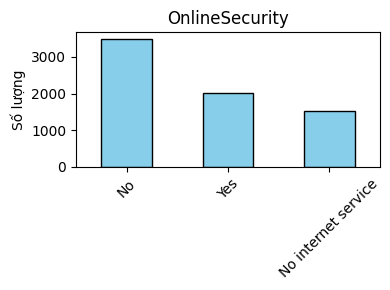

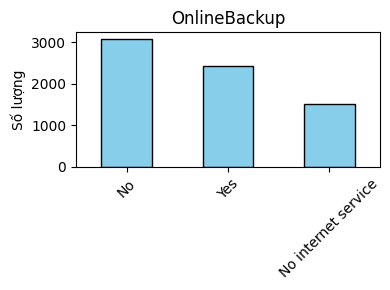

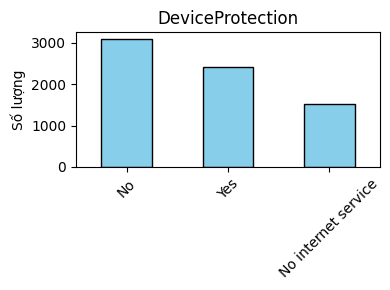

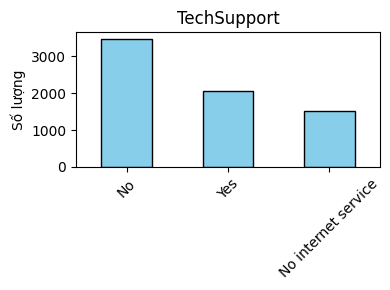

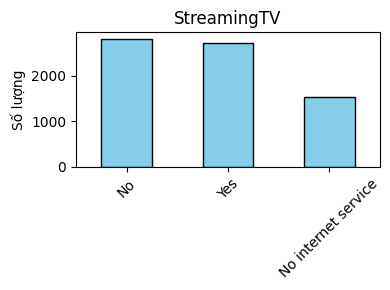

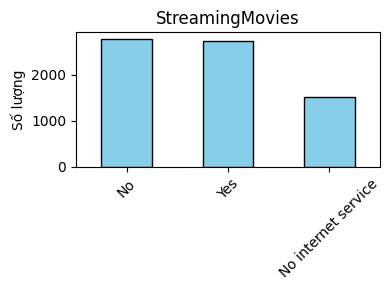

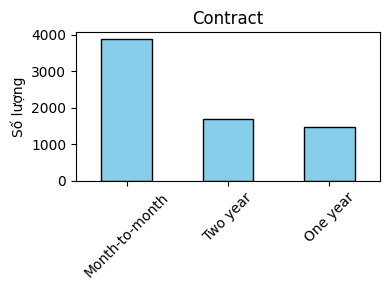

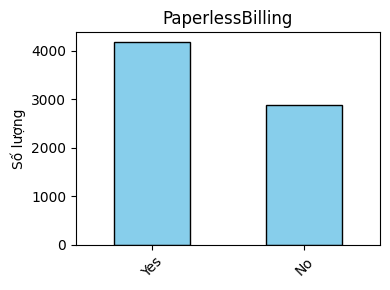

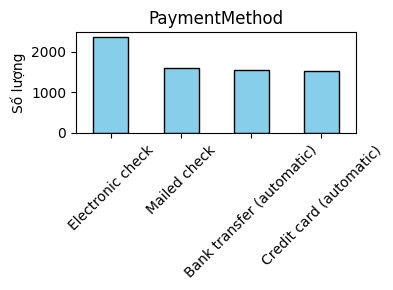

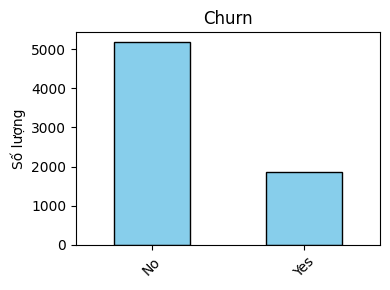

In [37]:
# Vẽ biểu đồ cột cho các đặc trưng phân loại
for column in categorical_columns:
    plt.figure(figsize=(4,3))
    plt.title(column)
    df[column].value_counts().plot(kind='bar', color="skyblue", edgecolor="black")
    plt.ylabel("Số lượng")
    plt.xlabel("")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Từ các biểu đồ trên, ta sẽ chia các đặc trưng kiểu phân loại thành 2 nhóm:
*   Nhóm chỉ có 2 giá trị khác nhau: gender, Partner, Dependents, SeniorCitizen,PhoneService, PaperlessBilling, Churn. Để mã hóa nhóm này, ta sẽ sử dụng phương pháp **Label Encoding**.
*   Nhóm có nhiều hơn 2 giá trị khác nhau: MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod. Để mã hóa nhóm này, ta sẽ sử dụng phương pháp **One-hot Encoding**.

Việc mã hóa sẽ được thực hiện trong phần **Feature Engineering**.

In [38]:
df[numeric_columns].agg(['min', 'max'])


,tenure,MonthlyCharges,TotalCharges
min,0,18.25,0.0
max,72,118.75,8684.8


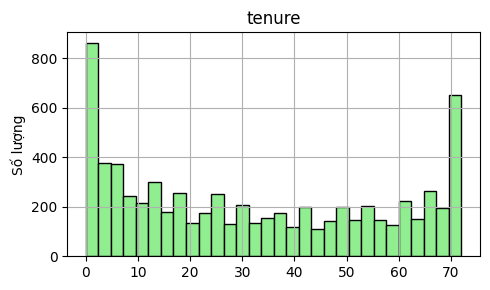

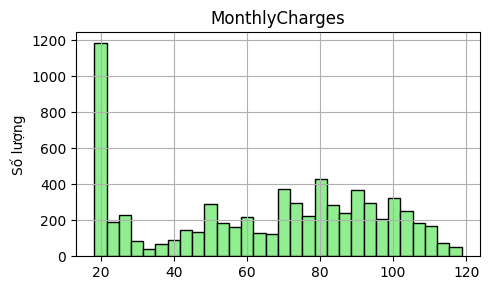

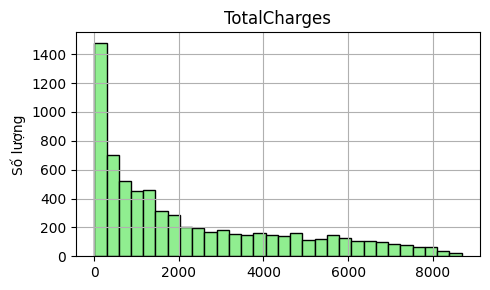

In [39]:
# Vẽ histogram cho các đặc trưng kiểu số
for column in numeric_columns:
    plt.figure(figsize=(5,3))
    df[column].hist(color="lightgreen", edgecolor="black", bins=30)
    plt.title(column)
    plt.xlabel("")
    plt.ylabel("Số lượng")
    plt.tight_layout()
    plt.show()

> Quan sát các biểu đó histogram ở trên, ta thấy các đặc trưng kiểu số có thang đo giá trị khác nhau.
*   **tenure**: khoảng từ 0 đến 75
*   **MonthlyCharges**: khoảng từ 18 đến 120
*   **TotalCharges**: khoảng từ 0 đến 8500

> Có thể thấy rõ giá trị trong **TotalCharges** được trải rộng trên khoảng giá trị lớn hơn nhiều so với **tenure** và **MonthlyCharges**.

> Do đó, ở phần **Feature Engineering**, nhóm sẽ sử dụng **Standard Scaler** để chuẩn hóa dữ liệu của các đặc trưng này về cùng một khoảng giá trị để giúp mô hình học tốt hơn, đặc biệt đối với các mô hình dựa trên khoảng cách như **K-Nearest Neighbors**, **Support Vector Machines** hoặc mô hình dựa trên gradient descent như **Logistic Regression**.

**Kiểm tra giá trị ngoại lai (Outliers)**

Để phát hiện Outlier, đầu tiên nhóm sẽ sử dụng biểu đồ **Boxplot** để trực quan, nhằm phát hiện nhanh các Outlier.

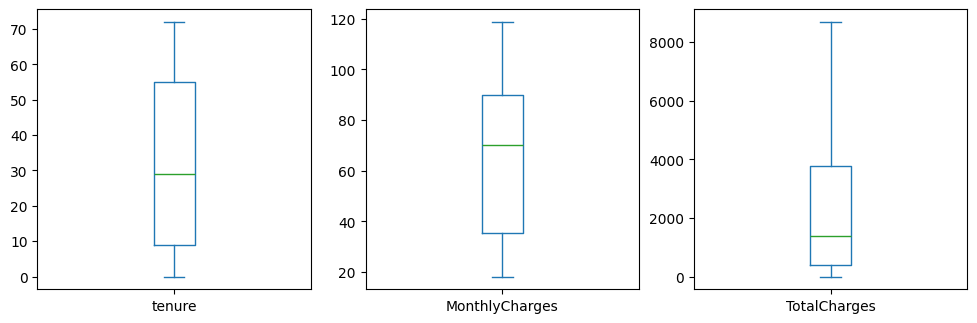

In [40]:
# Biểu đồ Boxplot phát hiện Outliers
df.plot(kind="box", subplots=True, figsize=(12, 8), layout=(2, 3))
plt.title("Numeric Columns Boxplot")
plt.show()

Dựa vào kết quả của các boxplot trên, có thể thấy rằng các đặc trưng số **không có dấu hiệu xuất hiện Outlier rõ ràng.**

Tiếp theo, nhóm sẽ sử dụng **phương pháp IQR** để **xác nhận** lại một lần nữa. Mục đích là để đảm bảo không tồn tại các Outlier tiềm ẩn hoặc khó nhận biết bằng boxplot trực quan.

In [41]:
# Hàm xác định ngưỡng phát hiện Outlier (Thresholds)
def define_threshold(dataset, column, q1=0.25, q3=0.75):
    q1 = dataset[column].quantile(q1)
    q3 = dataset[column].quantile(q3)
    iqr = q3 - q1
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr
    return lower_whisker, upper_whisker

# Hàm kiểm tra outlier cho các biến kiểu số
def check_outlier(dataset, column):
    lower_whisker, upper_whisker = define_threshold(dataset, column)
    if dataset[(dataset[column] < lower_whisker) | (dataset[column] > upper_whisker)].shape[0] > 0:
        print(column, ": ", len(dataset[(dataset[column] < lower_whisker) | (dataset[column] > upper_whisker)]), "outlier")
        return "Có Outlier"
    else:
        return "Không có Outlier"

for column in numeric_columns:
    print(column, ": ", check_outlier(df, column))

tenure :  Không có Outlier
MonthlyCharges :  Không có Outlier
TotalCharges :  Không có Outlier


Phương pháp **IQR** cũng cho kết quả là **không phát hiện Outlier**, do đó ta sẽ không cần thực hiện xử lý Outlier cho bộ dữ liệu.

# **5. Feature Engineering**

##**Mã hóa dữ liệu (Data Encoding)**

In [42]:
# Danh sách cột sử dụng One-hot encoding và Label Encoding
onehot_encode_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
label_encode_columns = ['gender', 'Partner', 'Dependents', 'SeniorCitizen', 'PhoneService', 'PaperlessBilling', 'Churn']

# One-hot encoding cho các cột phân loại có nhiều giá trị
df_encoded = pd.get_dummies(df, columns=onehot_encode_columns, drop_first=True)

# Label encoding cho các cột phân loại nhị phân
le = LabelEncoder()
for column in label_encode_columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Bộ dữ liệu sau khi mã hóa
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## **Chuẩn hóa dữ liệu (Data Scaling)**

In [43]:
# Chuẩn hóa bằng
scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_columns] = scaler.fit_transform(df_encoded[numeric_columns])

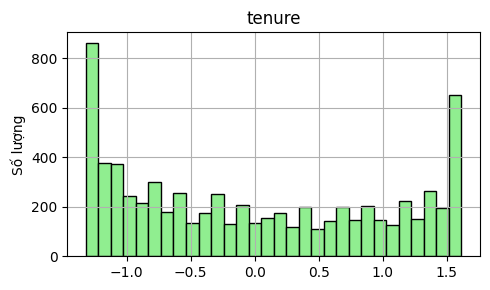

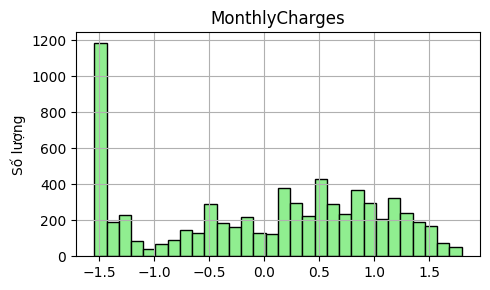

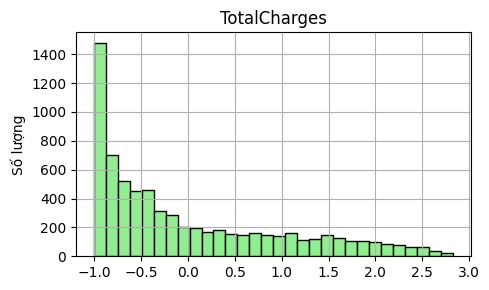

In [44]:
# Vẽ histogram cho các đặc trưng kiểu số sau khi chuẩn hóa
for column in numeric_columns:
    plt.figure(figsize=(5,3))
    df_scaled[column].hist(color="lightgreen", edgecolor="black", bins=30)
    plt.title(column)
    plt.xlabel("")
    plt.ylabel("Số lượng")
    plt.tight_layout()
    plt.show()

## **Gán biến X (biến đặc trưng) và biến y (biến mục tiêu)**

In [45]:
# Gán X và y
X = df_scaled.drop('Churn', axis=1)
y = df_scaled['Churn']

## **Chia dữ liệu thành bộ Train và bộ Test (Train-Test split)**

In [46]:
# Thực hiện Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
# Kiểm tra số lượng mẫu trong tập train và tập test
print("Số lượng mẫu trong tập train: ", X_train.shape[0])
print("Số lượng mẫu trong tập test: ", X_test.shape[0])
# Kiểm tra tỷ lệ % của lớp rời bỏ trong biến Churn
churn_yes_train = len(y_train[y_train == 1])
churn_no_train = len(y_train[y_train == 0])
churn_yes_test = len(y_test[y_test == 1])
churn_no_test = len(y_test[y_test == 0])
print("% Rời bỏ trong tập gốc: khoảng 26.54%")
print("% Rời bỏ trong tập train: ", churn_yes_train/(churn_yes_train + churn_no_train)*100)
print("% Rời bỏ trong tập test: ", churn_yes_test/(churn_yes_test + churn_no_test)*100)

Số lượng mẫu trong tập train:  5634
Số lượng mẫu trong tập test:  1409
% Rời bỏ trong tập gốc: khoảng 26.54%
% Rời bỏ trong tập train:  26.53532126375577
% Rời bỏ trong tập test:  26.54364797728886


#**6. Xây dựng mô hình**

## **Lựa chọn mô hình (Model Selection)**

Để lựa chọn mô hình cho bài toán, nhóm sẽ sử dụng phương pháp **K-Fold Cross-Validation** để xác định mô hình nào có tiềm năng nhất, thông qua chỉ số **Accuracy** trung bình của các fold.

**Xây dựng các mô hình**

In [48]:
# Xây dựng các model để lựa chọn
# 1. Logistic Regression
model_lr = LogisticRegression(random_state=42)
# 2. Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)
# 3. Random Forest
model_rf = RandomForestClassifier(random_state=42)
# 4. AdaBoost
model_ada = AdaBoostClassifier(random_state=42)
# 5. Gradient Boosting
model_gb = GradientBoostingClassifier(random_state=42)
# 6. XGBoost
model_xgb = XGBClassifier(random_state=42)
# 7. LightGBM
model_lgbm = lgb.LGBMClassifier(random_state=42, verbose=0)
# 8. K-Nearest Neighbors
model_knn = KNeighborsClassifier()
# 9. Support Vector Machines
model_svm = SVC(probability=True, random_state=42)

In [49]:
# Tạo dictionary lưu các model
models = {
    'Logistic Regression': model_lr,
    'Decision Tree': model_dt,
    'Random Forest': model_rf,
    'AdaBoost': model_ada,
    'Gradient Boosting': model_gb,
    'XGBoost': model_xgb,
    'LightGBM': model_lgbm,
    'K-Nearest Neighbors': model_knn,
    'Support Vector Machines': model_svm
}

In [50]:
# Tạo dictionary lưu kết quả cross-validation của tất cả model
cv_scores_of_all_models = {}
# Thực hiện k-fold cross-validation cho tất cả model
for model_name, model in models.items():
    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True
    )
    cv_scores_of_all_models[model_name] = cv_scores

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines


**Đánh giá Accuracy**

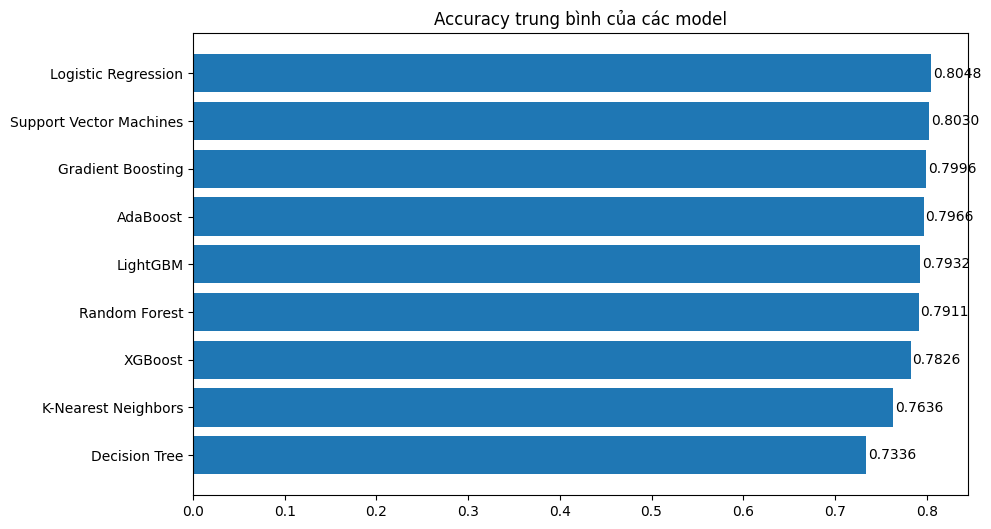


Thống kê chi tiết Accuracy của từng fold


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Accuracy (Mean),Std
Logistic Regression,0.831411,0.800355,0.805679,0.794144,0.792185,0.804755,0.014152
Support Vector Machines,0.821650,0.810115,0.802130,0.784383,0.796625,0.802981,0.012541
Gradient Boosting,0.817214,0.803904,0.811890,0.783496,0.781528,0.799606,0.014600
AdaBoost,0.822538,0.792369,0.802130,0.784383,0.781528,0.796589,0.014817
LightGBM,0.810115,0.802130,0.789707,0.782609,0.781528,0.793218,0.011194
Random Forest,0.806566,0.805679,0.794144,0.777285,0.771758,0.791086,0.014325
XGBoost,0.797693,0.787933,0.791482,0.771074,0.764654,0.782567,0.012570
K-Nearest Neighbors,0.773736,0.765750,0.764862,0.766637,0.746892,0.763575,0.008914
Decision Tree,0.735581,0.733807,0.728483,0.732032,0.738011,0.733583,0.003227


In [51]:
# Tạo bảng lưu Accuracy của từng model
accuracy_table = {}
for model_name in models:
    cv_scores = cv_scores_of_all_models[model_name]
    accuracies = cv_scores['test_accuracy']
    accuracy_table[model_name] = list(accuracies) + [np.mean(accuracies)] + [np.std(accuracies)]

columns = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'Accuracy (Mean)', 'Std']
accuracy_table = pd.DataFrame(accuracy_table, index=columns).T
accuracy_table = accuracy_table.sort_values(by='Accuracy (Mean)', ascending=False)

# Vẽ biểu đồ thể hiện Accuracy của từng mô hình từ cao đến thấp
plt.figure(figsize=(10, 6))
plt.barh(
    accuracy_table.index,
    accuracy_table['Accuracy (Mean)']
)
plt.title('Accuracy trung bình của các model')
plt.gca().invert_yaxis()
for i, v in enumerate(accuracy_table['Accuracy (Mean)']):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center')
plt.show()

print("\nThống kê chi tiết Accuracy của từng fold")
accuracy_table

Dựa vào biểu đồ và kết quả thống kê ở trên, có thể thấy **Logistic Regression** và **Support Vector Machines** có **Accuracy trung bình** cao nhất khoảng 80%. Như vậy để xác định mô hình nào phù hợp hơn, ta sẽ đánh giá thêm chỉ số **F1-Score**.

**Đánh giá F1-Score**

In [52]:
# Tạo bảng lưu F1-Score của Logistic Regression và Support Vector Machines
selected_models = {
    'Logistic Regression': models['Logistic Regression'],
    'Support Vector Machines': models['Support Vector Machines']
}
f1_score_table = {}
for model_name in selected_models:
    cv_scores = cv_scores_of_all_models[model_name]
    f1_scores = cv_scores['test_f1']
    f1_score_table[model_name] = list(f1_scores) + [np.mean(f1_scores)] + [np.std(f1_scores)]

columns = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'F1-Score (Mean)', 'Std']
f1_score_table = pd.DataFrame(f1_score_table, index=columns).T
f1_score_table = f1_score_table.sort_values(by='F1-Score (Mean)', ascending=False)
f1_score_table

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,F1-Score (Mean),Std
Logistic Regression,0.653285,0.581006,0.596685,0.581227,0.580645,0.598570,0.028028
Support Vector Machines,0.618596,0.570281,0.560158,0.533589,0.563810,0.569287,0.027641


Dựa vào kết quả trên có thể thấy rằng **Logistic Regresion** có **F1-Score trung bình** cao hơn **Support Vector Machines**, do đó nhóm sẽ chọn mô hình **Logistic Regression** cho bài toán dự đoán khách hàng rời bỏ.

**Kiểm tra Overfitting cho Logistic Regression**

In [53]:
# Lấy kết quả cross-validation của Logistic Regression
cv_scores = cv_scores_of_all_models['Logistic Regression']

# Xem Accuracy trung bình của tập train và tập validation
train_accuracy = cv_scores['train_accuracy']
validation_accuracy = cv_scores['test_accuracy']
print("Accuracy trung bình khi dự đoán trên tập train: ", np.mean(train_accuracy))
print("Accuracy trung bình khi dự đoán trên tập validation: ", np.mean(validation_accuracy))

# Kiểm tra chênh lệch giữa train và validation
accuracy_gap = np.mean(train_accuracy) - np.mean(validation_accuracy)
print("Chênh lệch giữa tập train và tập validation: ", accuracy_gap)

Accuracy trung bình khi dự đoán trên tập train:  0.805821674614801
Accuracy trung bình khi dự đoán trên tập validation:  0.8047546024356148
Chênh lệch giữa tập train và tập validation:  0.0010670721791862237


Có thể thấy rằng **chênh lệch độ chính xác** giữa tập train và tập validation rất nhỏ, khoảng **0,1%**. Do đó có thể xác nhận mô hình **Logistic Regression** này **không có hiện tượng Overfitting**. Tức là mô hình có khả năng dự đoán tốt trên cả dữ liệu huấn luyện và dữ liệu mới.

## **Huấn luyện mô hình và thực hiện dự đoán**

Lần này ta sẽ huấn luyện mô hình được chọn là **Logistic Regression** trên toàn bộ tập **train** và thực hiện dự đoán trên tập **test**.

In [54]:
# Huấn luyện mô hình
model_logistic = LogisticRegression(random_state=42)
model_logistic.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [55]:
# Thực hiện dự đoán trên tập test
y_predict = model_logistic.predict(X_test)

#**7. Đánh giá mô hình (Model Evaluation)**

**Confusion Matrix (Ma trận nhầm lẫn)**

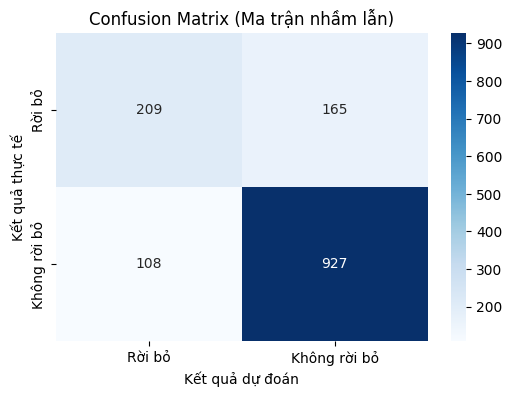

In [56]:
# Biểu diễn Confusion Matrix
cm = confusion_matrix(y_test, y_predict, labels=[1, 0])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rời bỏ', 'Không rời bỏ'],
            yticklabels=['Rời bỏ', 'Không rời bỏ'])
plt.ylabel('Kết quả thực tế')
plt.xlabel('Kết quả dự đoán')
plt.title('Confusion Matrix (Ma trận nhầm lẫn)')
plt.show()

**Classification Report**

In [57]:
# In Classification Report của mô hình
print("Classification Report của mô hình")
print(classification_report(y_test, y_predict))

Classification Report của mô hình
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



**ROC AUC Score**

In [58]:
# Tính xác suất dự đoán khách hàng rời bỏ
y_proba_churn = model_logistic.predict_proba(X_test)[:, 1]
# Tính ROC AUC Score
roc_auc = roc_auc_score(y_test, y_proba_churn)
print("ROC AUC Score: ", roc_auc)

ROC AUC Score:  0.8421788214627088


# **8. Giải thích mô hình và đề xuất giải pháp (Model Interpretation & Insights)**

## **Phân tích các đặc trưng quan trọng (Feature Importance Analysis)**

**Phân tích các hệ số của mô hình (Model Coefficients Analysis)**

Các hệ số (Coefficient) của mỗi đặc trưng cho biết mức độ ảnh hưởng đến khả năng rời bỏ của khách hàng.
*   Hệ số dương: đặc trưng làm tăng khả năng rời bỏ
*   Hệ số âm: đặc trưng làm giảm khả năng rời bỏ
*   Nếu giá trị tuyệt đối của Coefficient càng cao thì mức độ ảnh hưởng đến khả năng rời bỏ càng mạnh.

In [59]:
# Lưu hệ số của các đặc trưng trong mô hình
coefficients = model_logistic.coef_[0]
features = X_train.columns

# Tạo DataFrame biểu diễn
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

# Sắp xếp theo giá trị tuyệt đối giảm dần
feature_importance_df = feature_importance_df.sort_values(by='abs_coefficient', ascending=False)
print(feature_importance_df)

                                  Feature  Coefficient  abs_coefficient
26                      Contract_Two year    -1.328243         1.328243
4                                  tenure    -1.249330         1.249330
11            InternetService_Fiber optic     1.193660         1.193660
25                      Contract_One year    -0.685633         0.685633
8                            TotalCharges     0.519893         0.519893
5                            PhoneService    -0.500163         0.500163
7                          MonthlyCharges    -0.481375         0.481375
22                        StreamingTV_Yes     0.381099         0.381099
28         PaymentMethod_Electronic check     0.380941         0.380941
24                    StreamingMovies_Yes     0.380234         0.380234
6                        PaperlessBilling     0.370366         0.370366
10                      MultipleLines_Yes     0.364331         0.364331
14                     OnlineSecurity_Yes    -0.346818         0

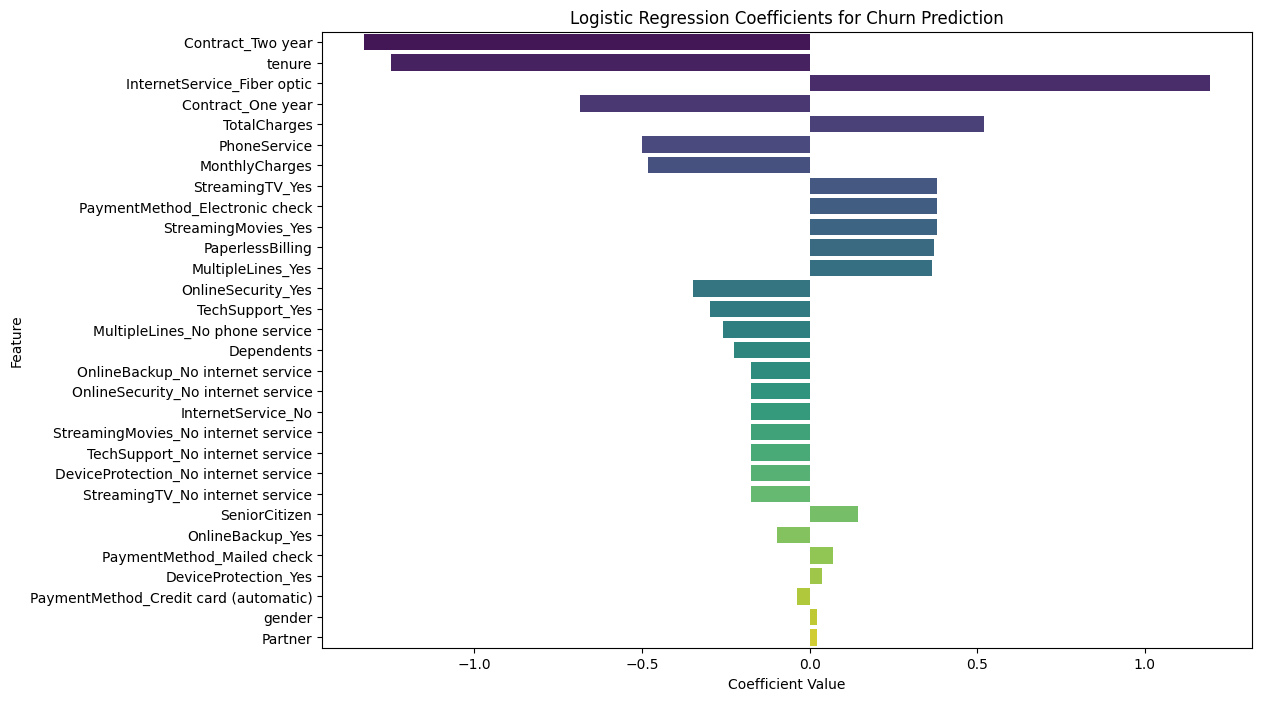

In [60]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Logistic Regression Coefficients for Churn Prediction')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

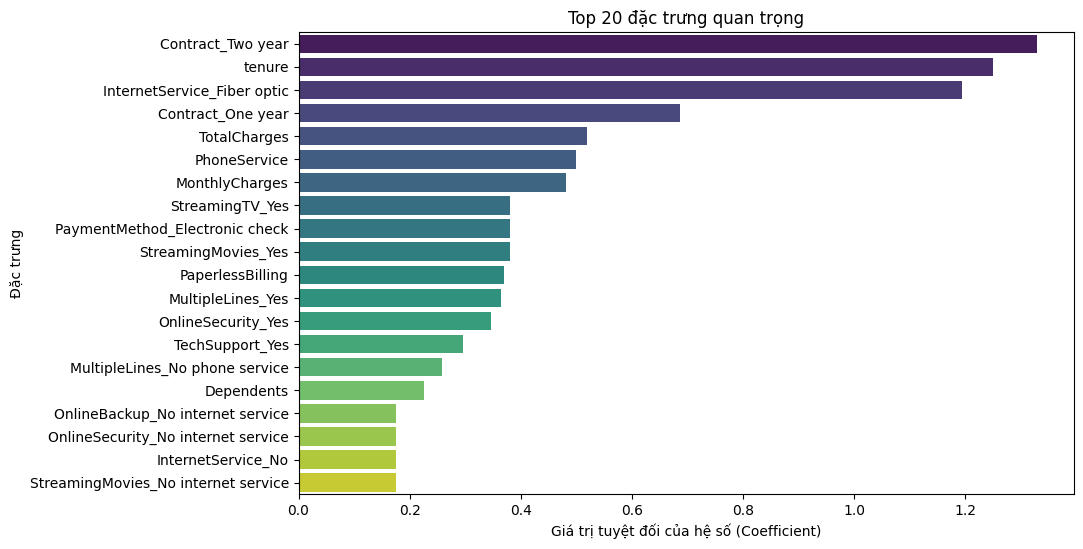

In [61]:
# Vẽ biểu đồ trực quan top 20 đặc trưng quan trọng
plt.figure(figsize=(10,6))
sns.barplot(x='abs_coefficient', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 đặc trưng quan trọng')
plt.xlabel('Giá trị tuyệt đối của hệ số (Coefficient)')
plt.ylabel('Đặc trưng')
plt.show()

**Đánh giá biểu đồ**

1. Các yếu tố làm giảm churn mạnh (hệ số âm lớn)
* Contract_Two year & Contract_One year

  Cho thấy độ cam kết tăng theo thời hạn hợp đồng → ít rời bỏ.

* Tenure

  Tenure càng cao → churn càng thấp.
  Khách hàng lâu năm thường trung thành hơn.

2. Các yếu tố làm tăng churn mạnh (hệ số dương lớn)
* InternetService_Fiber optic

  Là biến tăng churn mạnh nhất.

  Người dùng Fiber optic có kỳ vọng chất lượng cao → dễ thất vọng → churn cao.

* MonthlyCharges

  Chi phí hàng tháng cao → tăng khả năng rời bỏ.

* StreamingTV / StreamingMovies / PaperlessBilling / Electronic check

  Một số dịch vụ gia tăng liên quan đến internet hoặc hình thức thanh toán điện tử có hệ số dương, cho thấy mức độ rời bỏ cao hơn.


**SHAP Analysis**

Màu sắc:
*   Màu đỏ: thể hiện giá trị cao
*   Màu xanh: thể hiện giá trị thấp
*   Màu tím: thể hiện giá trị trung bình

Trục hoành x-axis: thể hiện giá trị Shap tác động lên đầu ra của mô hình






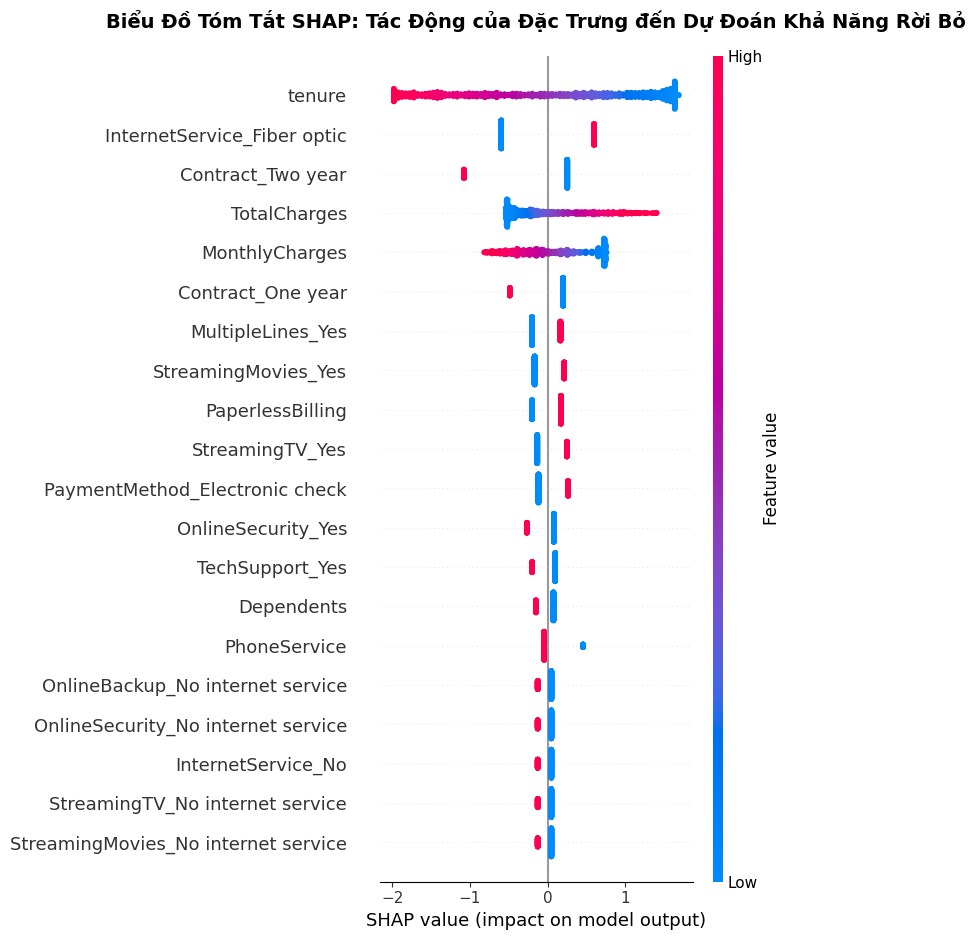

In [62]:
# tạo SHAP explainer
explainer = shap.LinearExplainer(model_logistic, X_train)

# Tính toán các giá trị SHAP trên tập con có 1000
X_test_subset_df = X_test[:1000]
# Chuyển đổi DataFrame thành NumPy Array -> hoạt động hiệu quả nhất
X_test_subset_array = X_test_subset_df.values

# Lấy các giá trị SHAP
raw_shap_values = explainer.shap_values(X_test_subset_array)

# Ép kiểu dữ liệu sang float
plot_shap_values = np.asarray(raw_shap_values, dtype=float)

# Biểu đồ tóm tắt SHAP
plt.figure(figsize=(12, 8))
shap.summary_plot(
    plot_shap_values,
    X_test_subset_df,
    feature_names=X.columns.tolist(),
    plot_type='dot',
    show=False
)
plt.title('Biểu Đồ Tóm Tắt SHAP: Tác Động của Đặc Trưng đến Dự Đoán Khả Năng Rời Bỏ', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Đánh giá biểu đồ**

Các Insight chính về khả năng rời bỏ

1. Các yếu tố tác động mạnh nhất
*   Tenure: những khách hàng có thời gian gấn bó thấp (màu xanh, nằm bên phải) có giá trị Shap dương mạnh -> khả năng rời bỏ cao. Ngược lại, thời gian gắn bó cao (màu đỏ, ở đầu bên trái) có giá trị SHAP âm, nghĩa là khách hàng trung thành (thời gian gắn bó lâu) có khả năng rời bỏ thấp.
*   InternetService_Fiber optic: những khách hàng có sử dụng fiber optic (màu đỏ, nằm bên phải) có giá trị Shap dương mạnh -> khả năng rời bỏ cao hơn với những khách sử dụng DSL hoặc không sử dụng.
*   Contract_Two year và Contract_One year: những khách hàng có hoặc đồng 1 hay 2 năm ( màu xanh, nằm bên trái ) có giá trị Shap âm mạnh -> khả năng rời bỏ thấp hơn với những khách hàng có hợp đông theo tháng.

2. Yếu tố gây rời bỏ (tác động dương)
*   MonthlyCharges: cước phí hàng tháng cao ( màu đỏ ), nằm bên phải có giá trị Shap cao -> tăng khả năng rời bỏ
*   PaymentMethod_Electronic check: Khách hàng sử dụng thanh toán qua Electronic check (màu đỏ, nằm bên phải) có xu hướng rời bỏ cao hơn.
*   PaperlessBilling: Sử dụng hóa đơn điện tử (Yes, màu đỏ) cũng làm tăng khả năng rời bỏ.

3.  Yếu tố giảm rời bỏ (Tác động âm)
*   TotalCharges:Tổng phí cao (màu đỏ, nằm bên trái) làm giảm khả năng rời bỏ. Điều này có thể do khách hàng đã gắn bó lâu và chi trả nhiều thì khả năng chuyển đổi nhà cung cấp thấp.
*   OnlineSecurity_Yes và TechSupport_Yes: (màu đỏ) đều có giá trị SHAP âm, cho thấy việc cung cấp các dịch vụ này giúp giảm khả năng rời bỏ.

4. Mối quan hệ đặc trưng

Tương phản chi phí: MonthlyCharges cao làm tăng churn, nhưng TotalCharges cao lại giảm churn. Điều này xác nhận rằng chi phí hiện tại cao là một vấn đề, trong khi tổng chi phí tích lũy cao lại là dấu hiệu của sự gắn bó lâu dài.


















## **Phân khúc khách hàng có nguy cơ rời bỏ cao**

Tính xác suất rời bỏ của khách hàng, in ra danh sách top N khách hàng được sắp xếp theo xác suất rời bỏ từ cao đến thấp và tính tỷ lệ dự đoán đúng trong tổng số khách hàng trong danh sách.

Bước này nhằm thử nghiệm tính ứng dụng của mô hình trong thực tế, hỗ trợ doanh nghiệp xác định được các khách hàng có xác suất rời bỏ cao.

In [63]:
# Tính xác suất rời bỏ của khách hàng
churn_prob = model_logistic.predict_proba(X_test)[:, 1]

# Tạo DataFrame gồm CustomerID, xác suất rời bỏ, kết quả thực tế
customer_id = dataset.loc[X_test.index, 'customerID']
churn_prediction_report = pd.DataFrame({
    'CustomerID': customer_id,
    'Xác suất rời bỏ': churn_prob,
    'Kết quả thực tế': y_test
})

# Số lượng khách hàng muốn in ra
number = 10

# In danh sách theo số lượng đã nhập
customer_list = churn_prediction_report.sort_values(by='Xác suất rời bỏ', ascending=False).head(number)
print("\nDanh sách top ", number, " khách hàng có nguy cơ rời bỏ (dựa vào xác suất dự đoán)\n")
print(customer_list.sort_values(by='Xác suất rời bỏ', ascending=False).head(number))

# Tính tỷ lệ khách hàng dự đoán đúng
churned_count = customer_list['Kết quả thực tế'].sum()
true_predict_percent = (churned_count / number)*100
print("\nSố lượng khách hàng thật sự rời bỏ: ", churned_count)
print("Tỷ lệ dự đoán đúng: ", true_predict_percent)


Danh sách top  10  khách hàng có nguy cơ rời bỏ (dựa vào xác suất dự đoán)

      CustomerID  Xác suất rời bỏ  Kết quả thực tế
3380  5178-LMXOP         0.855088                1
6866  0295-PPHDO         0.832337                1
2631  6861-XWTWQ         0.827991                1
6365  8884-ADFVN         0.822938                1
4585  1069-XAIEM         0.818858                1
3727  9057-SIHCH         0.818284                1
2797  6023-YEBUP         0.818100                1
3346  2545-EBUPK         0.817115                0
6894  1400-MMYXY         0.816686                1
935   6630-UJZMY         0.811260                0

Số lượng khách hàng thật sự rời bỏ:  8
Tỷ lệ dự đoán đúng:  80.0


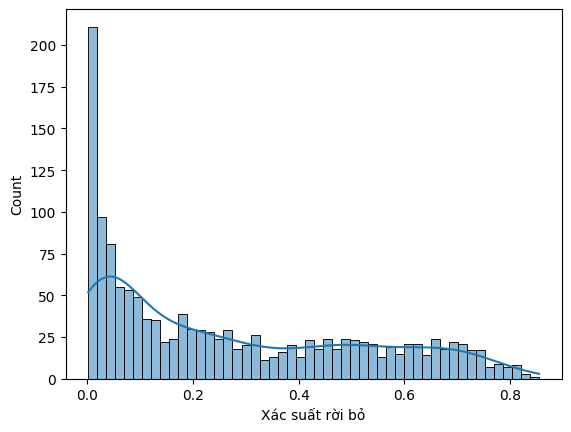

In [64]:
# Biểu đồ Histogram biểu diễn xác suất rời bỏ của khách hàng trong bộ test
sns.histplot(churn_prediction_report['Xác suất rời bỏ'], bins=50, kde=True)
plt.show()

In [65]:
# Xác định ngưỡng để chia phân khúc
high_risk_threshold = 0.7
medium_risk_threshold = 0.4

risk_segments = []

for prob in churn_prediction_report['Xác suất rời bỏ']:
    if prob >= high_risk_threshold:
        risk_segments.append('Rủi ro cao')
    elif prob >= medium_risk_threshold:
        risk_segments.append('Rủi ro trung bình')
    else:
        risk_segments.append('Rủi ro thấp')

churn_prediction_report['Phân khúc rủi ro'] = risk_segments

In [66]:
# Xem lại báo cáo
churn_prediction_report.head()

,CustomerID,Xác suất rời bỏ,Kết quả thực tế,Phân khúc rủi ro
437,4376-KFVRS,0.045652,0,Rủi ro thấp
2280,2754-SDJRD,0.683061,0,Rủi ro trung bình
2235,9917-KWRBE,0.059786,0,Rủi ro thấp
4460,0365-GXEZS,0.400128,0,Rủi ro trung bình
3761,9385-NXKDA,0.021511,0,Rủi ro thấp


In [67]:
# Xuất file csv báo cáo
churn_prediction_report.to_csv('churn_risk_customer.csv', index=False)

## **Đề xuất cho doanh nghiệp**

1. **Chiến lược giữ chân khách hàng khả thi (Contract & Tenure)**
* Đối tượng: những khách hàng có hợp đồng theo  tháng và dưới 6 tháng
* Insight Shap

  * tenure thấp (khách hàng mới < 12 tháng) -> Tăng Churn mạnh.

  Lý do: Khách hàng mới thường đang trong giai đoạn dùng thử hoặc vừa chuyển đổi, họ chưa thiết lập thói quen sử dụng, chưa chịu chi phí chuyển đổi cao, và nhạy cảm hơn với các vấn đề dịch vụ nhỏ. Đây là nhóm dễ bị đối thủ cạnh tranh thu hút nhất.
   * Contract_Two year và Contract_One year  cùng thấp -> Giảm Churn mạnh nhất  => Contract_Month to month cao -> làm tăng khả năng Churn.
   
    Lý do: Khách hàng Month-to-Month có thể hủy dịch vụ bất cứ lúc nào mà không phải chịu phí phạt nặng như khi hủy hợp đồng một năm hoặc hai năm. Điều này làm giảm đáng kể rào cản tài chính để họ chuyển sang đối thủ cạnh tranh.
* Hành động:

    * "Chương trình 6 tháng vàng": Tặng thêm dịch vụ miễn phí (ví dụ: Tăng băng thông tạm thời hoặc miễn phí dịch vụ Streaming TV) trong 6 tháng đầu để tạo sự gắn kết và trải nghiệm giá trị vượt trội ngay từ đầu -> Giảm tỷ lệ rời bỏ của nhóm khách hàng mới (Tenure dưới 6 tháng) ít nhất 15-20% trong quý tiếp theo.
    * "Gói nâng cấp thâm niên": Đưa ra ưu đãi giảm giá sâu 10-15% trên hóa đơn cho khách hàng chuyển từ hợp đồng 1 năm sang hợp đồng 2 năm -> Tăng tỷ lệ chuyển đổi Hợp đồng 1 năm sang 2 năm lên 30% so với cùng kỳ năm trước.
2. **Giải Quyết Vấn Đề Dịch vụ Cáp quang (Fiber Optic)**
* Đối tượng: những khách hàng sử dụng dịch vụ cáp quang ( có khả năng rời bỏ cao )
* Insight Shap
   * Khách hàng sử dụng cáp quang có tác động SHAP dương lớn -> Tăng khả năng rời bỏ.
   * OnlineSecurity_Yes và TechSupport_Yes -> Giảm Churn.
    
    Lý do: Dịch vụ cáp quang thường được bán với giá cao hơn và đi kèm với kỳ vọng về tốc độ và độ ổn định cao. Nếu công ty không đáp ứng được (ví dụ: thường xuyên bị rớt mạng, tốc độ không ổn định), sự thất vọng sẽ lớn hơn nhiều so với dịch vụ tiêu chuẩn. Khắc phục rủi ro cao từ InternetService_Fiber optic bằng cách thúc đẩy yếu tố giữ chân là OnlineSecurity/TechSupport.
* Hành động:
   * Cung cấp các dịch vụ Online Security và Tech Support miễn phí trong 3-6 tháng cho nhóm này. Điều này giải quyết cả nguyên nhân gây Churn (Fiber Optic) và thúc đẩy yếu tố giữ chân (Security/Support) -> Giảm tỷ lệ rời bỏ của nhóm Fiber Optic xuống mức trung bình chung của công ty trong vòng 6 tháng.
   * Triển khai chương trình đo lường và đền bù nếu tốc độ mạng trung bình hàng tháng không đạt 90% cam kết, truyền thông mạnh mẽ về cam kết này -> Giảm số lượng khiếu nại liên quan đến chất lượng mạng (Network Quality Complaints) của nhóm Fiber Optic xuống 25%.
3. **Tối ưu hóa chi phí và thanh toán (MonthlyCharges & PaymentMethod)**
* Insight Shap
  * MonthlyCharges cao ->Tăng Churn.
  * PaymentMethod_Electronic check -> Tăng Churn.

  Lý do: Chi phí cao làm khách hàng nhạy cảm về giá trị (tăng áp lực tài chính), trong khi việc thanh toán thủ công hàng tháng buộc họ phải liên tục tương tác và xem xét hóa đơn (tăng nhận thức về chi phí). Sự nhận thức chi phí cao và sự nhạy cảm về giá này khiến nhóm khách hàng này dễ dàng bị thu hút bởi các ưu đãi của đối thủ hoặc quyết định hủy dịch vụ ngay khi có vấn đề phát sinh, do họ không bị ràng buộc bởi hệ thống thanh toán tự động.
* Hành động:
  * Thay vì giảm giá, đề xuất các gói dịch vụ bổ sung miễn phí (ví dụ: Multiple Lines hoặc Streaming Movies) có giá trị tương đương với một khoản giảm giá nhỏ, để họ cảm thấy nhận được nhiều giá trị hơn với mức chi phí -> Tăng điểm hài lòng của khách hàng (CSAT) trong phân khúc khách hàng chi phí cao lên ít nhất 10%.
  * Tặng phiếu mua hàng hoặc giảm giá nhỏ trên hóa đơn tiếp theo (ví dụ: $5) cho khách hàng chuyển đổi phương thức thanh toán sang Bank transfer hoặc Credit card -> Tăng tỷ lệ khách hàng sử dụng thanh toán tự động (Auto-Pay Enrollment Rate) lên 15% trong quý.


  